# 프로젝트 : mini BERT 만들기

프로젝트 목표 : **vocab size를 8000으로 줄이고, 전체 파라미터 사이즈가 약 1M 수준인 아주 작은 mini BERT 모델**을 직접 만들어 **10 Epoch**까지 pretrain을 진행

진행 순서

1. Tokenizer 준비
2. 데이터 전처리 (1) MASK 생성
3. 데이터 전처리 (2) NSP pair 생성
4. 데이터 전처리 (3) 데이터셋 완성
5. BERT 모델 구현
6. pretrain 진행
7. 프로젝트 결과



## 0. 환경 준비
---
Colab 환경에 데이터/모델 디렉토리를 만들고, 학습에 사용할 한글 위키(kowiki) 코퍼스를 다운로드하여 압축을 해제합니다. 필요한 라이브러리도 설치합니다.

In [1]:
# 데이터와 모델을 저장할 디렉토리 생성
!mkdir -p /content/data
!mkdir -p /content/models

kowiki 코퍼스(zip)를 다운로드한 뒤 `/content/data` 아래에 압축을 해제합니다.

In [2]:
# kowiki 코퍼스 다운로드 및 압축 해제
!wget -nc https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
!mv kowiki.txt.zip /content/data
%cd /content/data
!unzip -o kowiki.txt.zip
%cd /content

--2026-07-15 07:28:50--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 13.249.182.14, 13.249.182.60, 13.249.182.118, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|13.249.182.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M   277MB/s    in 0.8s    

2026-07-15 07:28:51 (277 MB/s) - ‘kowiki.txt.zip’ saved [243123354/243123354]

/content/data
Archive:  kowiki.txt.zip
  inflating: kowiki.txt              
/content


실습에 필요한 라이브러리(`sentencepiece`, `tqdm`, `torchinfo`)를 설치합니다.

In [3]:
!pip install sentencepiece tqdm torchinfo

## 라이브러리 버전 확인
---
사용할 주요 라이브러리를 import 하고 버전을 확인합니다. 재현성을 위해 random seed도 고정합니다.

In [4]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

# random seed 고정
random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# 라이브러리 버전 확인
import numpy, pandas, matplotlib
print("torch      :", torch.__version__)
print("numpy      :", numpy.__version__)
print("pandas     :", pandas.__version__)
print("matplotlib :", matplotlib.__version__)
print("GPU 사용 가능 여부 :", torch.cuda.is_available())

torch      : 2.11.0+cu128
numpy      : 2.0.2
pandas     : 2.2.2
matplotlib : 3.10.0
GPU 사용 가능 여부 : True


## 1. Tokenizer 준비
---
SentencePiece를 이용해 **vocab_size 8000**의 BPE 토크나이저를 학습합니다.

BERT pretrain에 필요한 특수 토큰들(`[PAD]`, `[UNK]`, `[BOS]`, `[EOS]`, `[SEP]`, `[CLS]`, `[MASK]`)이 반드시 vocab에 포함되도록 `user_defined_symbols` 등의 옵션을 지정합니다. 그래서 실제 vocab 크기는 `8000 + 7 = 8007`이 됩니다.

> 코퍼스 크기가 크기 때문에 학습에 수십 분이 걸릴 수 있습니다. 이미 만들어 둔 `ko_8000.model` 파일이 있다면 이 셀은 건너뛰고 로딩 셀부터 실행해도 됩니다.

In [5]:
# vocab_size 8000의 sentencepiece 모델 학습
corpus_file = '/content/data/kowiki.txt'
prefix = '/content/models/ko_8000'
vocab_size = 8000

if not os.path.exists(f"{prefix}.model"):
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7}" +
        " --model_type=bpe" +
        " --max_sentence_length=999999" +
        " --pad_id=0 --pad_piece=[PAD]" +      # pad token 및 id 지정
        " --unk_id=1 --unk_piece=[UNK]" +      # unknown token 및 id 지정
        " --bos_id=2 --bos_piece=[BOS]" +      # begin of sentence token 및 id 지정
        " --eos_id=3 --eos_piece=[EOS]" +      # end of sentence token 및 id 지정
        " --user_defined_symbols=[SEP],[CLS],[MASK]")  # BERT용 특수 토큰
    print("sentencepiece 모델 학습 완료!")
else:
    print("이미 학습된 모델이 존재합니다.")

sentencepiece 모델 학습 완료!


학습된 sentencepiece 모델(`ko_8000.model`)을 로딩하고, vocab 크기를 확인합니다.

In [6]:
data_dir = '/content/data'
model_dir = '/content/models'

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_8000.model")

print("vocab size :", len(vocab))

vocab size : 8007


특수 토큰 7개를 제외한 나머지 토큰들로 `vocab_list`를 만들어 둡니다. 이후 MLM에서 랜덤 토큰으로 치환할 때 사용됩니다.

In [7]:
# 특수 token 7개를 제외한 나머지 token들의 목록 생성 (random 치환용)
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

print("vocab_list size :", len(vocab_list))
print(vocab_list[:50])

vocab_list size : 8000
['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동']


토크나이저가 잘 만들어졌는지 확인해 봅니다. 두 문장을 `[CLS] tokens_a [SEP] tokens_b [SEP]` 형태로 이어붙여 BERT 입력 형태의 토큰열을 만들어 봅니다.

In [8]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"

tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


## 2. 데이터 전처리 (1) MASK 생성
---
BERT의 Masked Language Model(MLM)을 위해 전체 토큰의 **15%**를 마스킹합니다. 마스킹 대상 중

- **80%**는 `[MASK]` 토큰으로 치환
- **10%**는 랜덤한 토큰으로 치환
- **10%**는 원래 토큰을 그대로 유지

합니다. 먼저 마스킹할 토큰 개수(`mask_cnt`)를 계산해 봅니다. (`[CLS]` 1개와 `[SEP]` 2개는 마스킹 대상에서 제외하므로 3을 빼줍니다.)

In [9]:
print(tokens_org)

# 전체 token의 15%를 mask ([CLS], [SEP] x2 제외)
mask_cnt = int((len(tokens_org) - 3) * 0.15)
print("mask_cnt :", mask_cnt)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']
mask_cnt : 14


Subword 단위로 일부만 마스킹하면 너무 쉽게 맞출 수 있으므로, **띄어쓰기(단어) 단위로 한꺼번에 마스킹**하기 위해 단어 단위의 index 목록(`cand_idx`)을 만듭니다. `▁`(▁)은 sentencepiece에서 단어의 시작을 의미합니다.

In [10]:
# 띄어쓰기 단위로 mask하기 위해서 index 분할
cand_idx = []  # word 단위의 index array
for (i, token) in enumerate(tokens_org):
    if token == "[CLS]" or token == "[SEP]":
        continue
    if 0 < len(cand_idx) and not token.startswith(u"▁"):  # u"▁"는 단어의 시작을 의미하는 값
        cand_idx[-1].append(i)
    else:
        cand_idx.append([i])

# 결과 확인
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

[1, 2, 3, 4] ['▁추', '적', '추', '적']
[5, 6] ['▁비', '가']
[7, 8] ['▁내', '리는']
[9, 10, 11] ['▁날', '이었', '어']
[12, 13, 14] ['▁그', '날', '은']
[15, 16, 17] ['▁', '왠', '지']
[18, 19, 20] ['▁손', '님', '이']
[21, 22] ['▁많', '아']
[23] ['▁첫']
[24, 25] ['▁번', '에']
[26, 27] ['▁삼', '십']
[28] ['▁전']
[29, 30, 31] ['▁둘', '째', '번']
[32, 33] ['▁오', '십']
[34] ['▁전']
[35, 36, 37] ['▁오', '랜', '만에']
[38, 39, 40] ['▁받아', '보', '는']
[41] ['▁십']
[42, 43, 44] ['▁전', '짜', '리']
[45, 46, 47] ['▁백', '통', '화']
[48, 49, 50] ['▁서', '푼', '에']
[52, 53, 54] ['▁손', '바', '닥']
[55, 56] ['▁위', '엔']
[57, 58, 59] ['▁기', '쁨', '의']
[60, 61] ['▁눈', '물이']
[62, 63] ['▁흘', '러']
[64, 65, 66] ['▁컬', '컬', '한']
[67, 68] ['▁목', '에']
[69, 70] ['▁모', '주']
[71, 72, 73] ['▁한', '잔', '을']
[74, 75] ['▁적', '셔']
[76] ['▁몇']
[77] ['▁달']
[78] ['▁포']
[79, 80] ['▁전', '부터']
[81, 82, 83, 84] ['▁콜', '록', '거', '리는']
[85] ['▁아내']
[86, 87] ['▁생각', '에']
[88, 89, 90] ['▁그', '토', '록']
[91, 92] ['▁먹', '고']
[93, 94, 95] ['▁싶', '다', '던']


무작위로 마스킹하기 위해 단어 단위 index 목록의 순서를 섞습니다.

In [11]:
# random mask를 위해서 index 순서를 섞음
random.shuffle(cand_idx)
cand_idx

[[24, 25],
 [57, 58, 59],
 [32, 33],
 [64, 65, 66],
 [41],
 [79, 80],
 [52, 53, 54],
 [67, 68],
 [29, 30, 31],
 [91, 92],
 [23],
 [26, 27],
 [76],
 [42, 43, 44],
 [78],
 [60, 61],
 [38, 39, 40],
 [93, 94, 95],
 [9, 10, 11],
 [81, 82, 83, 84],
 [85],
 [12, 13, 14],
 [34],
 [71, 72, 73],
 [77],
 [45, 46, 47],
 [48, 49, 50],
 [28],
 [74, 75],
 [62, 63],
 [88, 89, 90],
 [5, 6],
 [35, 36, 37],
 [55, 56],
 [18, 19, 20],
 [86, 87],
 [7, 8],
 [15, 16, 17],
 [1, 2, 3, 4],
 [21, 22],
 [69, 70]]

이제 위 로직을 종합하여, 섞인 단어 단위 index를 앞에서부터 순회하며 15%에 도달할 때까지 80/10/10 규칙으로 마스킹을 적용해 봅니다.

In [12]:
# tokens가 mask되므로 재실행을 위해서 복사본 사용 (테스트용)
tokens = copy.deepcopy(tokens_org)

mask_lms = []  # mask 된 값
for index_set in cand_idx:
    if len(mask_lms) >= mask_cnt:  # 현재 mask된 개수가 15%를 넘으면 중지
        break
    if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
        continue
    dice = random.random()  # 0과 1 사이의 확률 값

    for index in index_set:
        masked_token = None
        if dice < 0.8:  # 80% replace with [MASK]
            masked_token = "[MASK]"
        elif dice < 0.9:  # 10% keep original
            masked_token = tokens[index]
        else:  # 10% random word
            masked_token = random.choice(vocab_list)
        mask_lms.append({"index": index, "label": tokens[index]})
        tokens[index] = masked_token

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[MASK]', '[MASK]', '[MASK]', '▁삼', '십', '▁전', '▁둘', '째', '번', '[MASK]', '[MASK]', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '프', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘', '러', '[MASK]', '[MASK]', '[MASK]', '▁목', '에'

마스킹된 위치(`mask_idx`)와 원래 값(`mask_label`)을 index 순으로 정렬하여 MLM의 라벨 데이터로 정리합니다.

In [13]:
# 순서 정렬 및 mask_idx, mask_label 생성
mask_lms = sorted(mask_lms, key=lambda x: x["index"])
mask_idx = [p["index"] for p in mask_lms]
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

mask_idx   : [23, 24, 25, 32, 33, 41, 57, 58, 59, 64, 65, 66, 79, 80]
mask_label : ['▁첫', '▁번', '에', '▁오', '십', '▁십', '▁기', '쁨', '의', '▁컬', '컬', '한', '▁전', '부터']


### 🔶 create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드

위 과정을 하나의 함수로 정리합니다. 토큰열과 마스킹 개수, vocab 목록을 받아 (마스킹된 tokens, mask_idx, mask_label)을 반환합니다.

In [14]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"▁"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음
    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:  # mask 개수가 15%를 넘으면 중지
            break
        if len(mask_lms) + len(index_set) > mask_cnt:  # 15%를 넘게 되면 skip
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:  # 80% replace with [MASK]
                masked_token = "[MASK]"
            elif dice < 0.9:  # 10% keep original
                masked_token = tokens[index]
            else:  # 10% random word
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

`create_pretrain_mask()` 수행 결과를 확인해 봅니다.

In [15]:
# tokens가 mask되므로 재실행을 위해서 복사본 사용 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '[MASK]', '[MASK]', '[MASK]', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '팹', '著', '內', '[SEP]', '▁손', '바', '닥', '[MASK]', '[MASK]', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '[MASK]', '[MASK]', '▁한', 

## 3. 데이터 전처리 (2) NSP pair 생성
---
BERT의 또 다른 pretrain task인 **Next Sentence Prediction(NSP)**은 두 문장이 실제로 이어지는 문장인지 맞추는 문제입니다.

- 문장 A 다음에 실제로 문장 B가 이어지면 → `TRUE (IsNext, 1)`
- 순서를 뒤바꾸면 → `FALSE (NotNext, 0)`

아래 예시 텍스트로 NSP 학습 데이터를 만들어 봅니다. 먼저 줄 단위로 토크나이징합니다.

In [16]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'],
 ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아'],
 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전']]

sequence 최대 길이를 정합니다. `[CLS]`, `[SEP]`, `[SEP]` 3개의 특수 토큰이 들어가므로 실제 두 문장이 쓸 수 있는 최대 길이는 `n_test_seq - 3` 입니다.

In [17]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_test_seq - 3
print("max_seq :", max_seq)

max_seq : 61


doc의 줄들을 순서대로 쌓다가(`current_chunk`) 길이가 `max_seq` 이상이 되거나 마지막 줄에 도달하면, 랜덤한 위치(`a_end`)를 기준으로 앞부분을 `tokens_a`, 뒷부분을 `tokens_b`로 나누어 문장 pair를 만들어 봅니다.

In [18]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
        # 마지막 줄이거나 길이가 max_seq 이상인 경우 학습 데이터를 만듭니다.
        print("current_chunk:", len(current_chunk), current_length)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        print()

        current_chunk = []
        current_length = 0

current_chunk: 5 62
tokens_a: 50 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에']
tokens_b: 12 ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']

current_chunk: 6 71
tokens_a: 55 ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '▁살', '▁수', '▁있어', '▁집', '으로', '▁돌아', '가는', '▁길', '▁난', '▁문', '득', '▁떠', '올', '라']
tokens_b: 16 ['▁아내', '의', '▁목', '소', '리가', '▁거', '칠', '어', '만', '▁가는', '▁희', '박', '한', '▁숨', '소', '리가']

current_chunk: 5 73
tokens_a: 56 ['▁오늘', '은', '▁', '왠', '지', '▁나', '가지', '▁말', '라', '던', '▁내', '▁옆', '에', '▁있어', '▁달', '라', '던', '▁그리', '도', '▁나가', '고', '▁싶', 

두 문장의 길이 합이 `max_seq`를 넘지 않도록 잘라내는 `trim_tokens()` 함수를 정의합니다. token A가 더 길면 **앞에서부터**, token B가 더 길면 **뒤에서부터** 토큰을 제거합니다.

In [19]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 (최대 길이: max_seq)
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]   # tokens_a가 길면 앞에서 제거
        else:
            tokens_b.pop()    # tokens_b가 길면 뒤에서 제거

**50% 확률로 두 문장의 순서를 뒤바꾸어** true(`is_next=1`)/false(`is_next=0`) 케이스를 만들고, `trim_tokens()`로 길이를 조절하는 과정을 확인합니다.

In [20]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])
    current_length += len(doc[i])
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0   # False (NotNext)
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True (IsNext)
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        print()

        current_chunk = []
        current_length = 0

is_next: 0
tokens_a: 28 ['▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']
tokens_b: 33 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십']

is_next: 0
tokens_a: 39 ['▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '▁살', '▁수', '▁있어', '▁집', '으로', '▁돌아', '가는', '▁길', '▁난', '▁문', '득', '▁떠', '올', '라', '▁아내', '의', '▁목', '소', '리가', '▁거', '칠', '어', '만', '▁가는', '▁희', '박', '한', '▁숨', '소', '리가']
tokens_b: 22 ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내']

is_next: 1
tokens_a: 17 ['▁오늘', '은', '▁', '왠', '지', '▁나', '가지', '▁말', '라', '던', '▁내', '▁옆', '에', '▁있어', '▁달', '라', '던']
tokens_b: 44 ['▁그리', '도', '▁나가', '고', '▁싶', '으면', '▁일', '찍', '이라', '도', '▁들어', '와', '▁달', '라', '던', '▁아내', '의', '▁간', 

이제 두 문장 사이에 **segment 처리**를 합니다. 첫 번째 문장(`[CLS]` ~ 첫 번째 `[SEP]`)의 segment는 0, 두 번째 문장(~ 두 번째 `[SEP]`)은 1로 채웁니다.

동시에 앞에서 만든 `create_pretrain_mask()`를 함께 호출하여 **MLM + NSP가 결합된 하나의 학습 instance**를 완성합니다.

In [21]:
instances = []
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])
    current_length += len(doc[i])
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0   # False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        # tokens & segment 생성
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

        # mask 적용 (MLM)
        tokens, mask_idx, mask_label = create_pretrain_mask(
            tokens, int((len(tokens) - 3) * 0.15), vocab_list)

        instance = {
            "tokens": tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }
        instances.append(instance)

        current_chunk = []
        current_length = 0

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)
    print()

{'tokens': ['[CLS]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[MASK]', '[MASK]', '[MASK]', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[MASK]', '▁번', '에', '▁삼', '십', '가로', '[MASK]', '[MASK]', '▁번', '[MASK]', '[MASK]', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [25, 26, 27, 36, 41, 42, 43, 45, 46], 'mask_label': ['▁그', '날', '은', '▁첫', '▁전', '▁둘', '째', '▁오', '십']}

{'tokens': ['[CLS]', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '暴', '°', '[SEP]', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', 

### 🔶 create_pretrain_instances() : Next Sentence Prediction을 위한 코퍼스 생성 메소드

위 과정을 하나의 함수로 정리합니다. 하나의 doc(단락)으로부터 NSP + MLM instance 목록을 생성합니다.

In [22]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    :param vocab: sentencepiece vocab
    :param doc: 줄 단위로 tokenize된 문서
    :param n_seq: 최대 sequence 길이
    :param mask_prob: mask 확률 (0.15)
    :param vocab_list: random token 치환용 vocab 목록
    :return instances: pretrain instance 목록
    """
    # [CLS], [SEP], [SEP] 3개의 특수 토큰 자리 확보
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            # token a / token b 분리
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 50% 확률로 swap하여 NSP label 생성
            if random.random() < 0.5:
                is_next = 0   # False
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1   # True

            # 최대 길이 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # tokens, segment 생성
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # MLM mask 적용
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

`create_pretrain_instances()` 수행 결과를 확인해 봅니다.

In [23]:
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)
    print()

{'tokens': ['[CLS]', '▁번', '에', '▁삼', '십', '[MASK]', '▁둘', '째', 'え', '▁오', '십', '▁전', '▁오', '랜', '만에', '[MASK]', '[MASK]', '[MASK]', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [5, 8, 15, 16, 17, 36, 37, 38, 39], 'mask_label': ['▁전', '▁번', '▁받아', '보', '는', '▁눈', '물이', '▁흘', '러']}

{'tokens': ['[CLS]', '[MASK]', '[MASK]', '▁몇', '▁달', '[MASK]', '▁전', '부터', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '[MASK]', '▁수', '▁있어', '▁집', 

## 4. 데이터 전처리 (3) 데이터셋 완성
---
이제 실제 코퍼스인 `kowiki.txt` 전체에 전처리를 적용하여 BERT pretrain 데이터셋을 완성합니다. 먼저 전체 라인 수를 확인합니다.

In [24]:
corpus_file = '/content/data/kowiki.txt'

# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

print("총 라인 수 :", total)

총 라인 수 : 3957761


위키 문서는 빈 줄을 경계로 도큐먼트(단락)가 구분되는 형태입니다. 도큐먼트가 주제별로 잘 나눠지는지 몇 개만 확인해 봅니다.

In [25]:
# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈 줄일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)

  0%|          | 0/3957761 [00:00<?, ?it/s]

21 lines : ['▁지', '미', '▁카', '터']

14 lines : ['▁수학']

4 lines : ['▁수학', '▁상', '수']

10 lines : ['▁문학']

10 lines : ['▁나라', '▁목록']



### 🔶 make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드

전체 코퍼스를 단락 단위로 읽어 `create_pretrain_instances()`를 적용하고, 그 결과를 **json 라인 포맷**으로 저장하는 함수를 정의합니다.

In [26]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):  # unknown인 경우는 제거
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈 줄일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # 빈 줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

전체 코퍼스에 대해 `make_pretrain_data()`를 실행하여 pretrain용 json 데이터셋을 생성합니다. 10여 분 이상 소요될 수 있습니다.

In [27]:
pretrain_json_path = '/content/data/bert_pre_train.json'

if not os.path.exists(pretrain_json_path):
    make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)
else:
    print("이미 생성된 pretrain 데이터가 존재합니다.")

  0%|          | 0/3957761 [00:00<?, ?it/s]

생성된 json 데이터셋의 전체 라인(instance) 수를 확인합니다.

In [28]:
# 라인 수 확인
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
print("총 instance 수 :", total)

총 instance 수 : 918173


### 🔶 load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수

생성된 json 파일은 GB 단위로 큽니다. 일반 numpy array 대신 **`np.memmap`**을 사용해 디스크 기반으로 데이터를 다루어 메모리 사용량을 최소화합니다.

- `enc_tokens` : encoder 입력 token id (총 instance 수 × n_seq)
- `segments` : segment id
- `labels_nsp` : NSP 정답 (0/1)
- `labels_mlm` : MLM 정답 (마스킹된 위치에만 원래 token id, 나머지는 0)

In [29]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 적은 메모리에서도 대용량 데이터 처리가 가능함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

메모리와 학습 시간을 고려하여 **128,000건**만 로딩합니다.

In [30]:
# 128000건만 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


로딩된 데이터의 처음과 마지막 값을 확인합니다.

In [31]:
# 처음과 마지막 데이터 확인
print("enc_tokens[0]  :", pre_train_inputs[0][0][:20], "...")
print("enc_tokens[-1] :", pre_train_inputs[0][-1][:20], "...")
print("segments[0]    :", pre_train_inputs[1][0][:20], "...")
print("labels_nsp[0], labels_nsp[-1] :", pre_train_labels[0][0], pre_train_labels[0][-1])
print("labels_mlm[0]  :", pre_train_labels[1][0][:20], "...")

enc_tokens[0]  : [   5 3629  203  241 3602 1114 3724  788  243   49 3632  796    6 1648
 3682 3682 3625  203    6    6] ...
enc_tokens[-1] : [   5    6 2375 3608 3604  533 2589 3599  307  323 2143  321 3611  622
  123 3725 3620 3627 3837 3608] ...
segments[0]    : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ...
labels_nsp[0], labels_nsp[-1] : 0 1
labels_mlm[0]  : [   0    0    0    0    0    0    0    0    0    0    0    0  663    0
    0    0    0    0 3009 3625] ...


## 5. BERT 모델 구현
---
이제 BERT 모델을 구현합니다. BERT는 Transformer encoder 구조에 **Token / Position / Segment 3개의 embedding**을 더해 사용하는 것이 특징입니다.

먼저 pad mask, ahead mask 등 유틸리티 함수부터 정의합니다.

In [32]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수 (BERT에서는 사용하지 않지만 참고용으로 구현)
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

activation으로는 ReLU 대신 **GELU**를 사용합니다. GELU는 일반적으로 ReLU나 ELU보다 성능이 좋다고 알려져 있습니다.

$$0.5 \times x \times \left( 1 + \tanh \left[ \sqrt{2/\pi} (x + 0.044715x^3) \right] \right)$$

In [33]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

parameter initializer 생성 함수와, json을 config 형태로 사용하기 위한 `Config` 유틸리티 클래스를 정의합니다.

In [34]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_


def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_


class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

**Token Embedding** 레이어입니다. 입력 token을 embedding하는 `embedding` 모드와, MLM 출력 시 vocab 크기의 logits로 되돌리는 `linear` 모드를 하나의 weight로 공유(**weight sharing**)합니다.

In [35]:
class SharedEmbedding(nn.Module):
    """
    Weight Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드 (embedding or linear)
        :return: embedding or linear 실행 결과
        """
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행 (embedding weight를 재사용하여 vocab logits 계산)
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs

**Position Embedding** 레이어입니다. Transformer의 사인/코사인 Positional Encoding과 달리, BERT는 위치 정보를 **학습 가능한 embedding**으로 표현하여 입력에 더해줍니다.

In [36]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1  # (bs, n_seq) 위치 index
        position = position.long()
        embed = self.embedding(position)
        return embed

Transformer의 핵심인 **Scale Dot Product Attention**과 이를 여러 head로 확장한 **Multi Head Attention**을 구현합니다. Segment Embedding은 매우 간단하므로 별도 레이어 없이 BERT 클래스에서 `nn.Embedding(2, d_model)`로 처리할 예정입니다.

In [37]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: attention mask
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)  # mask 위치는 큰 음수로 만들어 softmax에서 제외
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: attention mask
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V: (bs, n_head, n_seq, d_head)
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        # attn_mask 변환: head 차원 추가
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)

        # (bs, n_seq, n_head, d_head)로 변환 후 (bs, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)  # (bs, n_seq, d_model)

        return attn_out

**Position Wise Feed Forward**와 이를 활용한 **Transformer Encoder 레이어**를 구성합니다. Encoder 레이어는 (Self-Attention → Add & Norm → Feed Forward → Add & Norm)의 residual 구조입니다.

In [38]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val


class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

이제 **BERT 레이어**를 구성합니다. Token / Position / Segment 3개 embedding을 더한 후 LayerNorm을 적용하고, Encoder 레이어들을 통과시킵니다.

출력은 두 가지입니다.

- `logits_cls` : `[CLS]` 토큰 위치의 출력 (NSP용)
- `logits_lm` : 각 토큰 위치의 vocab logits (MLM용, embedding weight 공유)

In [39]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 출력 (NSP용)
        :return logits_lm: Masked Language Modeling 예측 (MLM용)
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]  # [CLS] 위치의 출력
        logits_lm = self.embedding(enc_out, mode="linear")  # vocab logits
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding + position embedding + segment embedding
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

마지막으로 pretrain용 모델을 완성합니다. `PooledOutput`은 `[CLS]` 출력을 받아 NSP(2 class) logits를 만들어 주는 레이어입니다. `PreTrainModel`은 BERT + PooledOutput을 묶어 NSP logits와 MLM logits를 함께 출력합니다.

In [40]:
class PooledOutput(nn.Module):
    """
    [CLS] 출력을 NSP logits로 변환하는 Class
    """
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: logits (softmax 미적용; CrossEntropyLoss가 내부 처리)
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs


class PreTrainModel(nn.Module):
    """
    BERT pretrain 모델 (NSP + MLM)
    """
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        outputs_nsp = self.pooled_output(logits_cls)  # NSP raw logits
        outputs_mlm = logits_lm                       # MLM raw logits
        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)

### mini BERT config 정의

전체 파라미터가 **약 1M**이 되도록 모델 크기를 정합니다.

| 하이퍼파라미터 | 값 |
|---|---|
| n_vocab | 8007 (8000 + 특수토큰 7) |
| d_model | 96 |
| n_layer | 2 |
| n_head | 4 (d_head 24) |
| d_ff | 384 |
| n_seq | 128 |

- Token Embedding: 8007 × 96 ≈ 769K
- Encoder 2 layers ≈ 224K
- 기타(Position/Segment/PooledOutput 등) ≈ 22K
- **합계 ≈ 1.01M**

In [41]:
config = Config({
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,
    "dropout": 0.1,
    "d_ff": 384,
    "layernorm_epsilon": 0.001,
    "n_layer": 2,
    "n_seq": 128,
    "n_vocab": len(vocab),   # 8007
    "i_pad": vocab.pad_id()  # 0
})
config

{'d_model': 96,
 'n_head': 4,
 'd_head': 24,
 'dropout': 0.1,
 'd_ff': 384,
 'layernorm_epsilon': 0.001,
 'n_layer': 2,
 'n_seq': 128,
 'n_vocab': 8007,
 'i_pad': 0}

`torchinfo.summary`로 모델을 빌드하고 전체 파라미터 수가 약 1M인지 확인합니다.

In [42]:
from torchinfo import summary

mini_bert_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mini_bert_model.to(device)

# 전체 파라미터 수 확인
total_params = sum(p.numel() for p in mini_bert_model.parameters())
print(f"전체 파라미터 수 : {total_params:,} (~{total_params/1e6:.2f}M)")

summary(mini_bert_model,
        input_data=[torch.randint(0, config.n_vocab, (2, config.n_seq)).to(device),
                    torch.randint(0, 2, (2, config.n_seq)).to(device)])

전체 파라미터 수 : 1,014,528 (~1.01M)


Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [2, 2]                    --
├─BERT: 1-1                                                  [2, 96]                   --
│    └─SharedEmbedding: 2-1                                  [2, 128, 96]              768,672
│    └─PositionEmbedding: 2-2                                [2, 128, 96]              --
│    │    └─Embedding: 3-1                                   [2, 128, 96]              12,288
│    └─Embedding: 2-3                                        [2, 128, 96]              192
│    └─LayerNorm: 2-4                                        [2, 128, 96]              192
│    └─Dropout: 2-5                                          [2, 128, 96]              --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [2, 128, 96]           

## 6. pretrain 진행
---
학습에 필요한 loss / accuracy 함수를 먼저 정의합니다.

- **MLM loss** : 마스킹된 위치(라벨이 0이 아닌 위치)만 loss에 반영하고, MLM을 더 잘 학습하도록 **20배** 증가시킵니다.
- **MLM acc** : 마스킹된 위치에서만 정확도를 계산합니다.

In [43]:
def lm_loss(y_true, y_pred):
    """
    MLM loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1).long(), reduction='none')
    # pad(0)인 부분 mask
    mask = (y_true.view(-1) != 0).float()
    loss = loss * mask
    return loss.sum() / mask.sum().clamp(min=1) * 20   # MLM을 더 잘 학습하도록 20배 증가


def lm_acc(y_true, y_pred):
    """
    MLM acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1)
    matches = (y_true == y_pred_class).float()
    # pad(0)인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

**Learning Rate 스케줄링**을 구현합니다. warmup 구간 동안 선형으로 증가한 후, cosine 형태로 감소하는 스케줄입니다.

In [44]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

스케줄이 의도대로 동작하는지 learning rate 곡선을 그려 확인합니다.

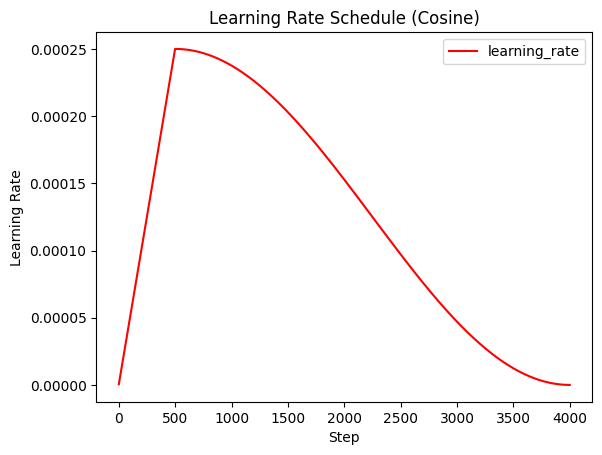

In [45]:
# learning rate 곡선 확인
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

학습 데이터를 `TensorDataset` / `DataLoader`로 구성합니다. 메모리 오류를 피하기 위해 데이터는 CPU에 두고 **배치 단위로만 GPU로 이동**합니다. 배치 사이즈는 GPU 메모리 상황에 맞게 조절하세요 (OOM 발생 시 64 → 32로 축소).

In [46]:
epochs = 10
batch_size = 128

# memmap → tensor 변환 (CPU에 유지)
train_dataset = TensorDataset(
    torch.tensor(np.array(pre_train_inputs[0]), dtype=torch.long),
    torch.tensor(np.array(pre_train_inputs[1]), dtype=torch.long),
    torch.tensor(np.array(pre_train_labels[0]), dtype=torch.long),
    torch.tensor(np.array(pre_train_labels[1]), dtype=torch.long),
)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("총 배치 수 / epoch :", len(train_dataloader))

총 배치 수 / epoch : 1000


optimizer는 **Adam**을 사용하고, 총 학습 step 수에 맞춰 CosineSchedule을 설정합니다. NSP loss는 `CrossEntropyLoss`, MLM loss는 앞에서 정의한 `lm_loss`를 사용합니다.

In [47]:
# optimizer & scheduler
train_steps = len(train_dataloader) * epochs
print("train_steps:", train_steps)

learning_rate_scheduler = CosineSchedule(
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10),
    max_lr=2.5e-4)

optimizer = optim.Adam(mini_bert_model.parameters(), lr=1e-4)
loss_fn_nsp = nn.CrossEntropyLoss()

train_steps: 10000


이제 본격적으로 **10 Epoch** 학습을 진행합니다. 매 step마다 NSP loss + MLM loss를 합산해 역전파하고, learning rate를 스케줄에 따라 갱신합니다. 매 epoch이 끝나면 모델을 저장하고, loss / accuracy를 history에 기록합니다.

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mini_bert_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

for epoch in range(epochs):
    mini_bert_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        # 배치 단위로만 GPU로 이동
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = [b.to(device) for b in batch]
        optimizer.zero_grad()

        logits_nsp, logits_mlm = mini_bert_model(enc_tokens_batch, segments_batch)

        # loss 계산 (NSP: CrossEntropy, MLM: lm_loss - 마스킹 위치만, 20배 가중)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm)

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()

        # learning rate 스케줄 적용
        lr = learning_rate_scheduler.step()
        for g in optimizer.param_groups:
            g['lr'] = lr

        # accuracy 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = lm_acc(labels_mlm_batch, logits_mlm)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # epoch 결과 저장
    n_batches = len(train_dataloader)
    history['nsp_loss'].append(total_nsp_loss / n_batches)
    history['mlm_loss'].append(total_mlm_loss / n_batches)
    history['nsp_acc'].append(total_nsp_acc / n_batches)
    history['mlm_acc'].append(total_mlm_acc / n_batches)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / n_batches:.4f}, "
          f"NSP Loss: {history['nsp_loss'][-1]:.4f}, MLM Loss: {history['mlm_loss'][-1]:.4f}, "
          f"NSP Acc: {history['nsp_acc'][-1]:.4f}, MLM Acc: {history['mlm_acc'][-1]:.4f}")

    # 모델 저장
    torch.save(mini_bert_model.state_dict(), f"{model_dir}/mini_bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 158.0868, NSP Loss: 0.6557, MLM Loss: 157.4311, NSP Acc: 0.5775, MLM Acc: 0.0255


Epoch 2/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 148.8502, NSP Loss: 0.6158, MLM Loss: 148.2344, NSP Acc: 0.5978, MLM Acc: 0.0289


Epoch 3/10:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 8/10 - Loss: 140.0500, NSP Loss: 0.5899, MLM Loss: 139.4601, NSP Acc: 0.6010, MLM Acc: 0.0539


Epoch 9/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 139.5749, NSP Loss: 0.5894, MLM Loss: 138.9856, NSP Acc: 0.6018, MLM Acc: 0.0562


Epoch 10/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 139.4213, NSP Loss: 0.5897, MLM Loss: 138.8316, NSP Acc: 0.6028, MLM Acc: 0.0569


## 7. 프로젝트 결과
---
10 Epoch 동안 기록된 NSP / MLM의 loss와 accuracy를 시각화하여, 학습이 안정적으로 수렴하는지 확인합니다.

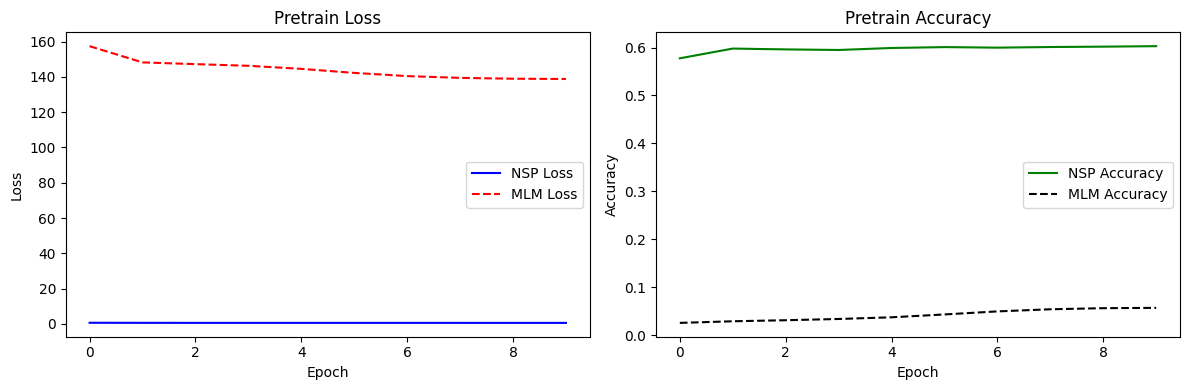

In [49]:
# 학습 결과 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Pretrain Loss')

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Pretrain Accuracy')

plt.tight_layout()
plt.show()

epoch별 수치를 표로도 정리해 봅니다.

In [50]:
# epoch별 학습 결과 요약
result_df = pd.DataFrame({
    'epoch': range(1, len(history['nsp_loss']) + 1),
    'nsp_loss': history['nsp_loss'],
    'mlm_loss': history['mlm_loss'],
    'nsp_acc': history['nsp_acc'],
    'mlm_acc': history['mlm_acc'],
})
result_df

,epoch,nsp_loss,mlm_loss,nsp_acc,mlm_acc
0,1,0.655673,157.431109,0.577477,0.025543
1,2,0.615821,148.234417,0.597820,0.028917
2,3,0.599114,147.244907,0.596070,0.031089
3,4,0.593951,146.311014,0.594859,0.033705
4,5,0.592974,144.567006,0.599016,0.037201
5,6,0.591777,142.282760,0.600875,0.043160
6,7,0.591165,140.461102,0.599727,0.049519
7,8,0.589923,139.460097,0.601039,0.053943
8,9,0.589352,138.985582,0.601812,0.056212
9,10,0.589704,138.831644,0.602812,0.056918


### 결과 분석

- **NSP loss**는 초반부터 비교적 빠르게 감소하며, NSP accuracy가 0.5(랜덤 수준)를 넘어 점차 상승한다면 두 문장의 호응 관계를 모델이 학습하고 있다는 의미입니다.
- **MLM loss**는 vocab 8000개 중 정답 토큰을 맞춰야 하는 훨씬 어려운 문제이므로 천천히 감소합니다. MLM accuracy가 조금씩이라도 꾸준히 오르는지가 중요합니다.
- 모델 파라미터가 약 1M으로 매우 작고 데이터도 일부(128,000건)만 사용했기 때문에, loss가 완만하게 수렴하거나 진동할 수 있습니다. 이는 모델 용량의 한계로 자연스러운 현상입니다.

## 회고
---

**배운 점**

- BERT pretrain의 전체 파이프라인(토크나이저 학습 → MLM/NSP 데이터 전처리 → 모델 구현 → 학습)을 직접 구현하며, pretrained model이 만들어지는 과정을 처음부터 끝까지 경험할 수 있었다.
- 모델 구현 자체보다 **코퍼스를 태스크에 맞는 데이터셋으로 가공하는 전처리 과정이 훨씬 큰 비중**을 차지한다는 것을 체감했다. 특히 MLM의 80/10/10 마스킹 규칙, 띄어쓰기(단어) 단위 마스킹, NSP의 50% swap과 segment 구성 등 세부 규칙 하나하나가 학습 품질에 직결된다.
- 1.4GB에 달하는 대용량 json 데이터셋을 다루면서 `np.memmap`으로 메모리 사용량을 최소화하는 방법을 익혔다.
- BERT가 Transformer encoder에 Token/Position/Segment 3가지 embedding을 더해 사용하는 구조, embedding weight를 MLM 출력층과 공유하는 weight sharing 기법, warmup + cosine decay 학습률 스케줄링을 직접 구현하며 이해를 깊게 했다.

**어려웠던 점**

- vocab size 8000, 파라미터 약 1M이라는 제약에 맞춰 d_model, n_layer, d_ff 등을 조합하는 과정에서, 파라미터 대부분이 embedding(약 770K)에 몰려 있어 encoder에 쓸 수 있는 용량이 매우 제한적이었다.
- 작은 모델 용량 탓에 MLM loss가 정식 BERT처럼 시원하게 떨어지지는 않았다. loss가 수렴하지 않는 것이 버그 때문인지 모델 한계 때문인지 판단하는 데 시간이 걸렸다.

**아쉬운 점 및 다음에 시도해 볼 것**

- 전체 데이터 중 128,000건만 사용했는데, 더 많은 데이터와 더 긴 학습으로 성능 변화를 관찰해 보고 싶다.
- MLM loss 20배 가중치, learning rate, warmup 비율 등 하이퍼파라미터를 체계적으로 탐색하면 더 안정적인 수렴을 얻을 수 있을 것 같다.
- 이렇게 pretrain한 mini BERT를 실제 downstream task(예: NSMC 감성 분류)에 fine-tuning하여 pretrain의 효과를 검증해 보고 싶다.

**정리**

작지만 완전한 BERT를 밑바닥부터 만들어 pretrain까지 완주했다는 점에서 의미가 큰 프로젝트였다. "pretrained model은 결국 좋은 데이터 파이프라인과 안정적인 학습 설계의 산물"이라는 것을 몸으로 배웠다.